## Рубежный контроль №1 

**Дисциплина:** Технологии разведочного анализа и обработки данных

**Вариант:** 17 (Задача №3, датасет №1 — Iris)

**Группа:** ИУ5-66Б

**ФИО:** Рухлин А. В.

---

### Задача №3
Для заданного набора данных произвести:
- масштабирование данных (для одного признака);
- преобразование категориальных признаков в количественные двумя способами (**label encoding**, **one hot encoding**) для одного признака.

Доп. требование для группы **ИУ5-66Б**: построить **парные диаграммы (pairplot)**.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

# чтобы графики были крупнее
plt.rcParams["figure.figsize"] = (10, 6)

In [7]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()

# Приведём названия колонок к удобному виду
rename_map = {
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
    "target": "species_id",
}
df = df.rename(columns=rename_map)

# Добавим читаемое имя класса
species_names = {i: name for i, name in enumerate(iris.target_names)}
df["species"] = df["species_id"].map(species_names)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species_id    150 non-null    int64  
 5   species       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


### Парные диаграммы (требование для ИУ5-66Б)

Построим `pairplot` по числовым признакам, окрашивая точки по виду ириса.

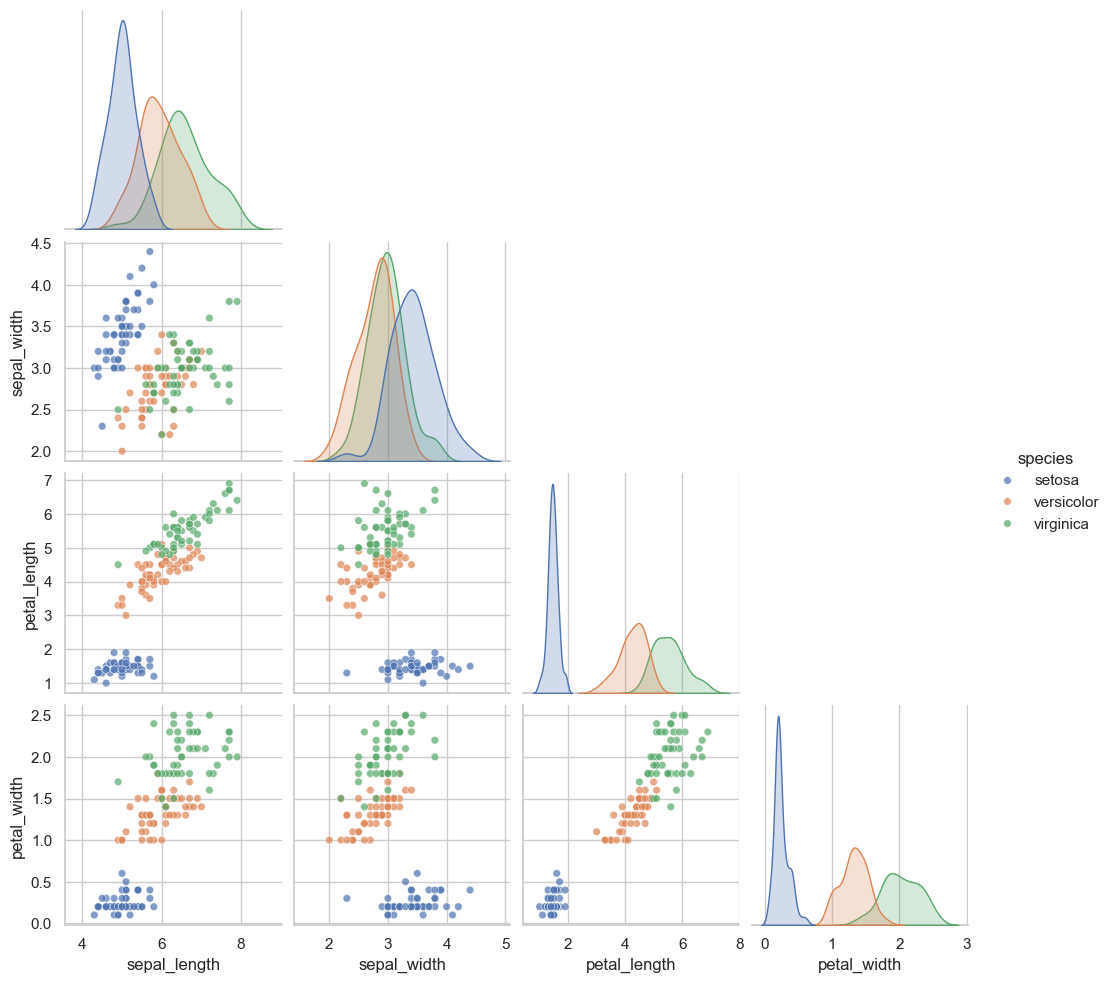

In [9]:
num_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

sns.pairplot(df[num_cols + ["species"]], hue="species", corner=True, plot_kws={"alpha": 0.7, "s": 30})
plt.show()

### 1) Подготовка категориального признака

В Iris исходно все 4 признака — числовые. По примечанию в задании, если категориальных признаков нет, их можно создать искусственно.

Создадим категориальный признак `petal_length_cat`, разбив `petal_length` на 3 группы (квантили): `short / medium / long`.

In [10]:
df2 = df.copy()

# Разобьём длину лепестка на 3 категории по квантилям
bins = 3
labels = ["short", "medium", "long"]
df2["petal_length_cat"] = pd.qcut(df2["petal_length"], q=bins, labels=labels)

df2[["petal_length", "petal_length_cat", "species"]].head(10)

,petal_length,petal_length_cat,species
0,1.4,short,setosa
1,1.4,short,setosa
2,1.3,short,setosa
3,1.5,short,setosa
4,1.4,short,setosa
5,1.7,short,setosa
6,1.4,short,setosa
7,1.5,short,setosa
8,1.4,short,setosa
9,1.5,short,setosa


In [11]:
df2["petal_length_cat"].value_counts().sort_index()

petal_length_cat
short     50
medium    54
long      46
Name: count, dtype: int64

### 2) Преобразование категориального признака двумя способами

Далее закодируем **один** категориальный признак `petal_length_cat` двумя способами:

- **Label encoding**: заменяем категории на целые числа (подходит для *порядковых* категорий; у нас порядок есть: short < medium < long).
- **One-hot encoding**: создаём отдельные бинарные колонки на каждую категорию (универсальный способ для *номинальных* категорий, не навязывает порядка).

In [ ]:
le = LabelEncoder()

df2["petal_length_cat_le"] = le.fit_transform(df2["petal_length_cat"].astype(str))

pd.DataFrame({
    "category": le.classes_,
    "label": range(len(le.classes_))
})

,category,label
0,long,0
1,medium,1
2,short,2


In [13]:
df2[["petal_length_cat", "petal_length_cat_le"]].head(10)

,petal_length_cat,petal_length_cat_le
0,short,2
1,short,2
2,short,2
3,short,2
4,short,2
5,short,2
6,short,2
7,short,2
8,short,2
9,short,2


In [ ]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

ohe_arr = ohe.fit_transform(df2[["petal_length_cat"]].astype(str))
ohe_cols = [f"petal_length_cat__{c}" for c in ohe.categories_[0]]

df_ohe = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df2.index)

df_ohe.head()

,petal_length_cat__long,petal_length_cat__medium,petal_length_cat__short
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


### 3) Масштабирование одного числового признака

Масштабируем **один** признак `sepal_length` методом **StandardScaler** (стандартизация):

- после преобразования признак имеет среднее  приблизительно 0 и стандартное отклонение  приблизительно 1;
- это полезно для моделей, чувствительных к масштабу (kNN, SVM, линейные модели с регуляризацией, нейросети и т.д.).

In [15]:
scaler = StandardScaler()

before_mean = df2["sepal_length"].mean()
before_std = df2["sepal_length"].std(ddof=0)

df2["sepal_length_scaled"] = scaler.fit_transform(df2[["sepal_length"]])

after_mean = df2["sepal_length_scaled"].mean()
after_std = df2["sepal_length_scaled"].std(ddof=0)

pd.DataFrame({
    "feature": ["sepal_length"],
    "mean_before": [before_mean],
    "std_before": [before_std],
    "mean_after": [after_mean],
    "std_after": [after_std],
})

,feature,mean_before,std_before,mean_after,std_after
0,sepal_length,5.843333,0.825301,-4.736952e-16,1.0


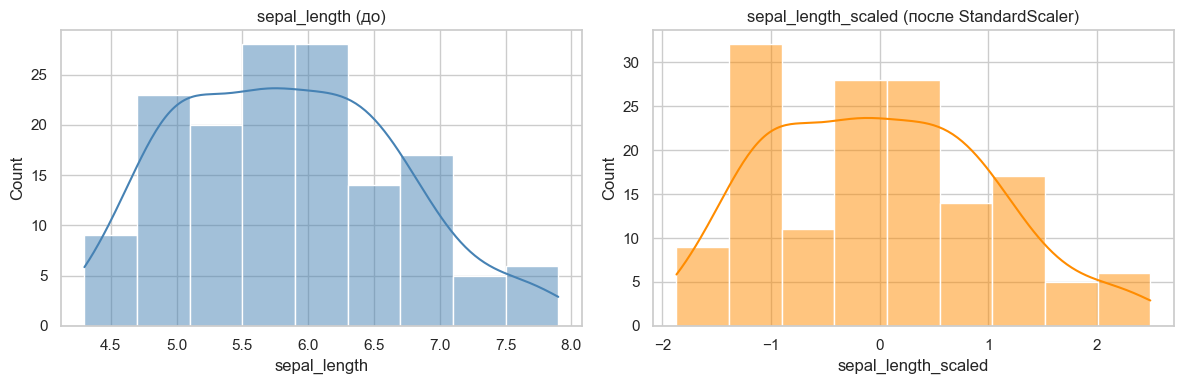

In [16]:
# Визуально сравним распределение до/после масштабирования
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df2["sepal_length"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("sepal_length (до)")

sns.histplot(df2["sepal_length_scaled"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("sepal_length_scaled (после StandardScaler)")

plt.tight_layout()
plt.show()